# Visualisasi Golden Dataset

Notebook ini memuat seluruh file `datasets/golden/*.json` dan menampilkan sebaran data untuk melihat area yang masih kurang pada golden dataset.


In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import csv
import json
import re
import sys

MAX_CSV_FIELD_SIZE = sys.maxsize
while True:
    try:
        csv.field_size_limit(MAX_CSV_FIELD_SIZE)
        break
    except OverflowError:
        MAX_CSV_FIELD_SIZE //= 10

import matplotlib.pyplot as plt
import polars as pl


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "datasets").is_dir():
            return candidate
    return current


try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = find_project_root(NOTEBOOK_DIR)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config

GOLDEN_DIR = config.DATASETS / "golden"
KABUPATEN_PATH = config.RESOURCES / "wilayah" / "kabupaten.csv"
FIGURE_DIR = config.FIGURES / "golden_dataset_distribution"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(GOLDEN_DIR)
print(FIGURE_DIR)


E:\School\tugas-akhir\project\datasets\golden
E:\School\tugas-akhir\project\outputs\figures\golden_dataset_distribution


## 1. Load Golden Dataset


In [2]:
def text_value(row):
    for key in ("text_selected", "text", "content"):
        value = row.get(key, "")
        if isinstance(value, str) and value.strip():
            return value.strip()
    return ""


def normalize_row(row, golden_file, row_number):
    text = text_value(row)
    return {
        "golden_file": golden_file,
        "golden_row": row_number,
        "text_id": str(row.get("text_id", "")).strip(),
        "sentiment": str(row.get("sentiment", row.get("label", ""))).strip() or "(kosong)",
        "location": str(row.get("location", "")).strip() or "(kosong)",
        "text": text,
        "text_length": len(text),
        "word_count": len(text.split()),
    }


rows = []
for path in sorted(GOLDEN_DIR.glob("*.json")):
    with path.open(encoding="utf-8") as file:
        payload = json.load(file)

    if isinstance(payload, list):
        iterable = payload
    elif isinstance(payload, dict):
        iterable = payload.get("data", payload.get("rows", []))
    else:
        iterable = []

    for row_number, row in enumerate(iterable, start=1):
        if isinstance(row, dict):
            rows.append(normalize_row(row, path.name, row_number))

df = pl.DataFrame(rows) if rows else pl.DataFrame({
    "golden_file": [],
    "golden_row": [],
    "text_id": [],
    "sentiment": [],
    "location": [],
    "text": [],
    "text_length": [],
    "word_count": [],
})

print(f"Jumlah file golden: {len(list(GOLDEN_DIR.glob('*.json')))}")
print(f"Jumlah baris golden: {df.height}")
with pl.Config(tbl_rows=10, tbl_cols=-1, fmt_str_lengths=120):
    display(df)


Jumlah file golden: 2
Jumlah baris golden: 163


golden_file,golden_row,text_id,sentiment,location,text,text_length,word_count
str,i64,str,str,str,str,i64,i64
"""1_sentiment_labeling_output.json""",1,"""RAW-0560#01""","""positif""","""Sambas""","""Optimalisasi pola operasi menghasilkan peningkatan rata-rata penetrasi energi terbarukan hingga 37.06%, mengurangi biaya…",377,51
"""1_sentiment_labeling_output.json""",2,"""RAW-0560#02""","""negatif""","""Sambas""","""Penelitian ini mengusulkan penggunaan teknologi artificial intelligence untuk memprediksi intensitas cahaya matahari, me…",256,29
"""1_sentiment_labeling_output.json""",3,"""RAW-0485#01""","""positif""","""Sintang""","""Saya Sangat Setuju dengan Statement dari utusan @kemenkop dan panelis yang lain nya pada meeting hari ini.""",106,17
"""1_sentiment_labeling_output.json""",4,"""RAW-0485#02""","""positif""","""Kalimantan Barat""","""Dan Masukan Saya Kepada Pemerintah, Mengingat KDMP Sulit memperoleh Dana Pinjaman. Alangkah baiknya Pemerintah Pusat ber…",289,38
"""1_sentiment_labeling_output.json""",5,"""RAW-0908#01""","""negatif""","""Bengkayang""","""Hal ini menunjukkan bahwa sejumlah proyek pembangkit listrik, seperti PLTU Bengkayang dan PLTU Parit Baru, mengalami pen…",165,23
…,…,…,…,…,…,…,…
"""2_sentiment_labeling_output.json""",124,"""RAW-1075#06""","""negatif""","""Landak""","""Sungguh Miris ud puluhan th Indonesia merdeka di berapa desa blm menikmati listrik""",82,13
"""2_sentiment_labeling_output.json""",125,"""RAW-1075#07""","""negatif""","""Landak""","""Sudah lagu lama kab Landak tak heran lagi sangat jauh tertinggal pembangunanya""",78,12
"""2_sentiment_labeling_output.json""",126,"""RAW-1075#08""","""negatif""","""Landak""","""Aku ngk tau gimana cara pengurus desa ngurusnya ya hal sepenting itu di take over ke desa org lain.""",99,19


## 2. Ringkasan Kualitas Data


In [3]:
summary_df = pl.DataFrame([
    {
        "metric": "total_rows",
        "value": df.height,
    },
    {
        "metric": "unique_text_id",
        "value": df.select(pl.col("text_id").n_unique()).item() if df.height else 0,
    },
    {
        "metric": "duplicate_text_id_rows",
        "value": df.height - df.select(pl.col("text_id").n_unique()).item() if df.height else 0,
    },
    {
        "metric": "empty_text_rows",
        "value": df.filter(pl.col("text") == "").height if df.height else 0,
    },
    {
        "metric": "empty_location_rows",
        "value": df.filter(pl.col("location") == "(kosong)").height if df.height else 0,
    },
    {
        "metric": "empty_sentiment_rows",
        "value": df.filter(pl.col("sentiment") == "(kosong)").height if df.height else 0,
    },
])

with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(summary_df)


metric,value
str,i64
"""total_rows""",163
"""unique_text_id""",163
"""duplicate_text_id_rows""",0
"""empty_text_rows""",0
"""empty_location_rows""",0
"""empty_sentiment_rows""",0


## 3. Fungsi Visualisasi


In [4]:
BAR_COLOR = "#2f6f9f"
GREEN_COLOR = "#3f7d20"
ORANGE_COLOR = "#8a5a00"
RED_COLOR = "#9f3a38"


def safe_filename(name):
    return "".join(char if char.isalnum() or char in "-_" else "_" for char in name).strip("_")


def finish_plot_grid(fig, filename):
    fig.tight_layout(pad=1.2)
    fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


def make_plot_grid(plot_count, row_height=4, col_width=6):
    cols = min(2, plot_count)
    rows_count = (plot_count + cols - 1) // cols
    fig, axes = plt.subplots(rows_count, cols, figsize=(col_width * cols, row_height * rows_count))
    if plot_count == 1:
        axes = [axes]
    else:
        axes = list(axes.ravel())
    for ax in axes[plot_count:]:
        ax.axis("off")
    return fig, axes


def value_counts(column, top=None):
    counts = Counter(row[column] for row in rows)
    return dict(counts.most_common(top))


def draw_bar_from_counts(ax, data, title, color=BAR_COLOR, rotate=45):
    labels = list(data.keys())
    values = list(data.values())

    ax.bar(labels, values, color=color)
    ax.set_title(title)
    ax.set_ylabel("Jumlah")
    ax.tick_params(axis="x", rotation=rotate)
    ax.grid(axis="y", alpha=0.25)


def draw_horizontal_from_counts(ax, data, title, color=BAR_COLOR):
    labels = list(data.keys())[::-1]
    values = list(data.values())[::-1]

    ax.barh(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Jumlah")
    ax.grid(axis="x", alpha=0.25)


def plot_count_grid(specs, filename, row_height=4, col_width=6):
    fig, axes = make_plot_grid(len(specs), row_height=row_height, col_width=col_width)
    for ax, spec in zip(axes, specs):
        spec = dict(spec)
        chart_type = spec.pop("chart_type", "bar")
        if chart_type == "horizontal":
            draw_horizontal_from_counts(ax, **spec)
        else:
            draw_bar_from_counts(ax, **spec)
    finish_plot_grid(fig, filename)


## 4. Sebaran File, Sentimen, dan Lokasi


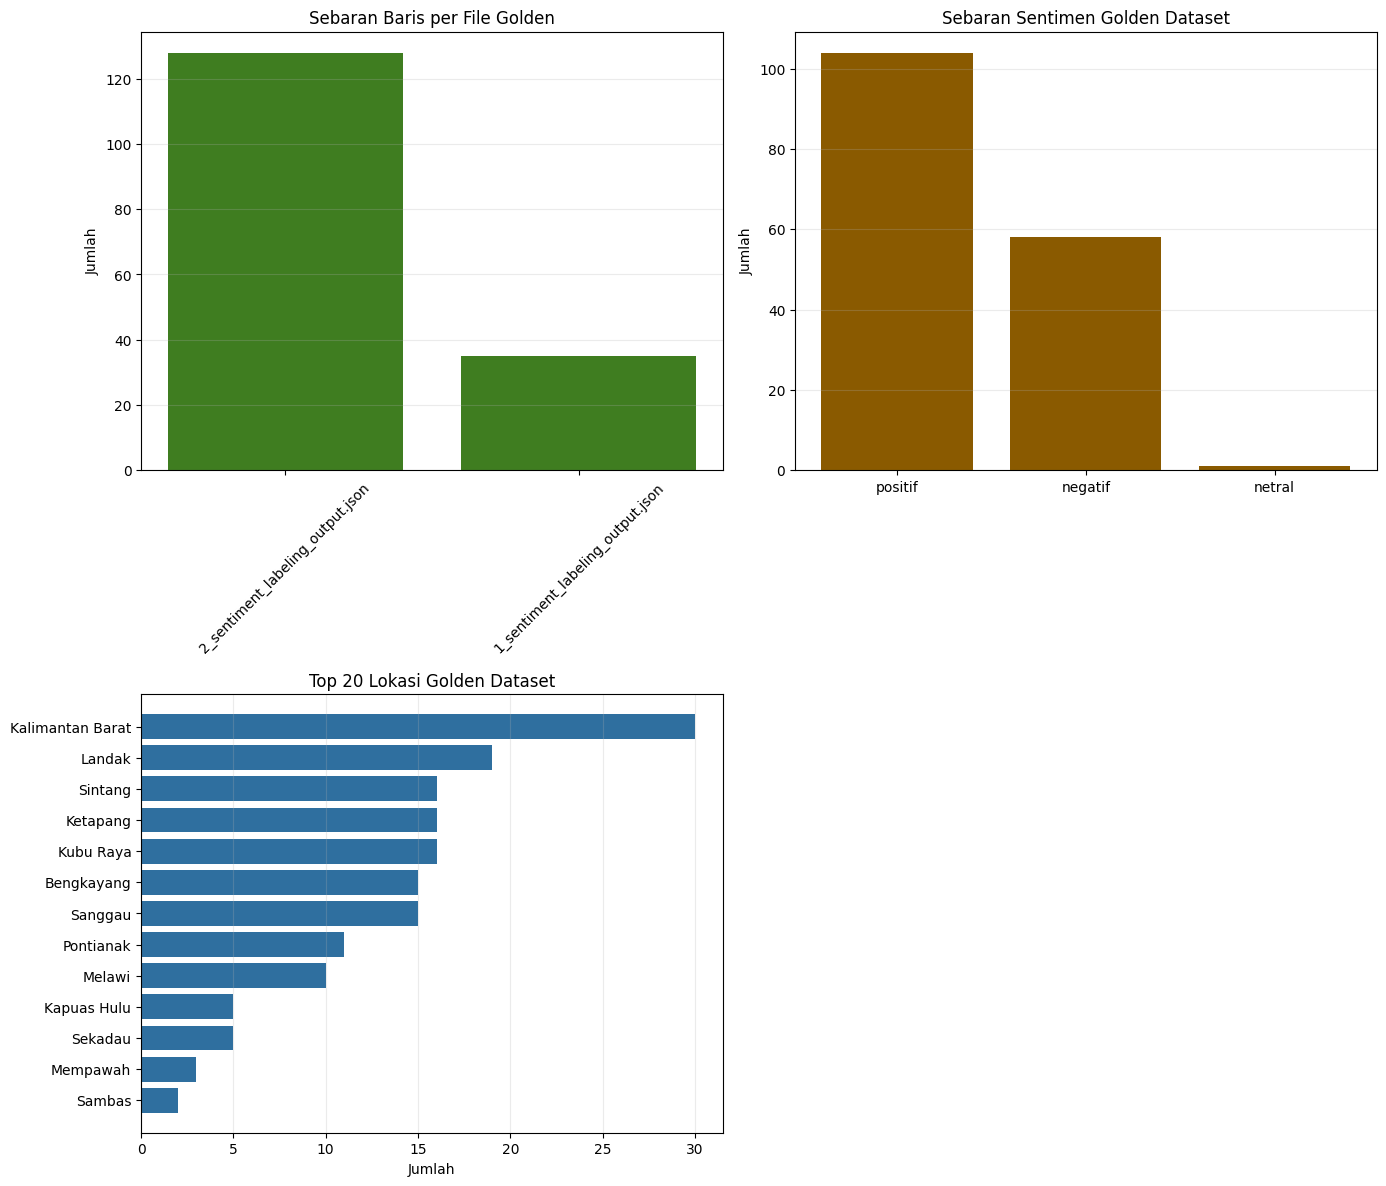

In [5]:
plot_count_grid(
    [
        {
            "data": value_counts("golden_file"),
            "title": "Sebaran Baris per File Golden",
            "color": GREEN_COLOR,
        },
        {
            "data": value_counts("sentiment"),
            "title": "Sebaran Sentimen Golden Dataset",
            "color": ORANGE_COLOR,
            "rotate": 0,
        },
        {
            "data": value_counts("location", top=20),
            "title": "Top 20 Lokasi Golden Dataset",
            "chart_type": "horizontal",
        },
    ],
    "golden_file_sentiment_location_distribution.png",
    row_height=6,
    col_width=7,
)


## 5. Kombinasi Sentimen dan Lokasi


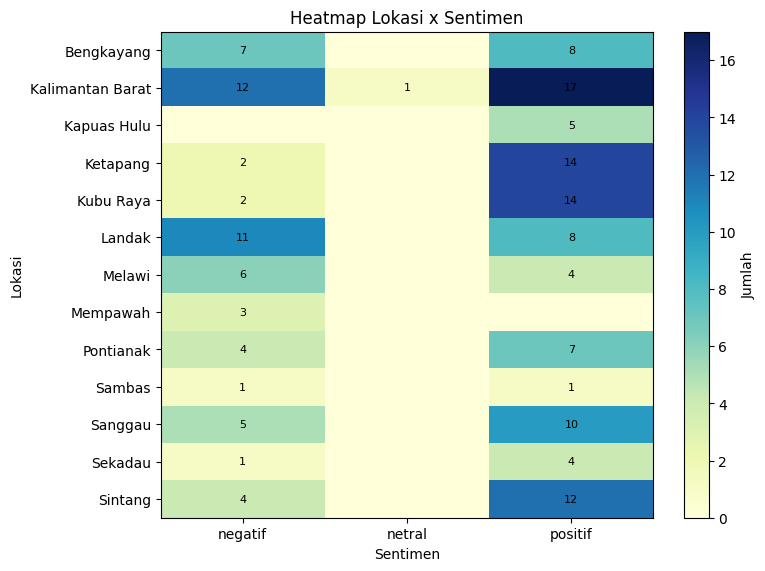

In [6]:
def cross_counts(row_key, col_key):
    row_values = sorted({row[row_key] for row in rows})
    col_values = sorted({row[col_key] for row in rows})
    counts = defaultdict(int)
    for row in rows:
        counts[(row[row_key], row[col_key])] += 1
    matrix = [[counts[(row_value, col_value)] for col_value in col_values] for row_value in row_values]
    return row_values, col_values, matrix


locations, sentiments, location_sentiment_matrix = cross_counts("location", "sentiment")

fig_height = max(5, min(14, len(locations) * 0.45))
fig, ax = plt.subplots(figsize=(8, fig_height))
image = ax.imshow(location_sentiment_matrix, aspect="auto", cmap="YlGnBu")
ax.set_title("Heatmap Lokasi x Sentimen")
ax.set_xticks(range(len(sentiments)), labels=sentiments)
ax.set_yticks(range(len(locations)), labels=locations)
ax.set_xlabel("Sentimen")
ax.set_ylabel("Lokasi")
for row_idx, values in enumerate(location_sentiment_matrix):
    for col_idx, value in enumerate(values):
        if value:
            ax.text(col_idx, row_idx, str(value), ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Jumlah")
finish_plot_grid(fig, "golden_location_sentiment_heatmap.png")


## 6. Sebaran Panjang Teks


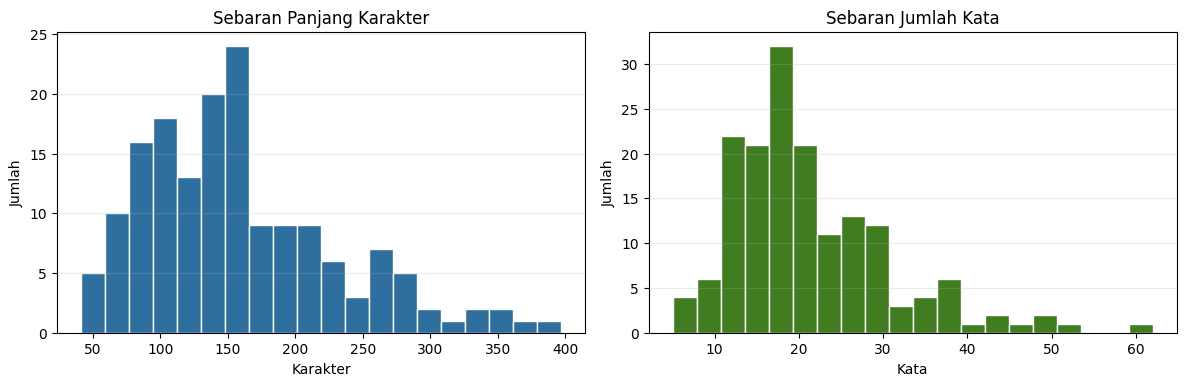

In [7]:
text_lengths = [row["text_length"] for row in rows]
word_counts = [row["word_count"] for row in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(text_lengths, bins=20, color=BAR_COLOR, edgecolor="white")
axes[0].set_title("Sebaran Panjang Karakter")
axes[0].set_xlabel("Karakter")
axes[0].set_ylabel("Jumlah")
axes[0].grid(axis="y", alpha=0.25)

axes[1].hist(word_counts, bins=20, color=GREEN_COLOR, edgecolor="white")
axes[1].set_title("Sebaran Jumlah Kata")
axes[1].set_xlabel("Kata")
axes[1].set_ylabel("Jumlah")
axes[1].grid(axis="y", alpha=0.25)

finish_plot_grid(fig, "golden_text_length_distribution.png")


## 7. Coverage Lokasi Kabupaten/Kota Kalimantan Barat


region,jumlah_golden,coverage_status
str,i64,str
"""Kayong Utara""",0,"""belum_ada"""
"""Singkawang""",0,"""belum_ada"""
"""Landak""",19,"""tersedia"""
"""Ketapang""",16,"""tersedia"""
"""Kubu Raya""",16,"""tersedia"""
"""Sintang""",16,"""tersedia"""
"""Bengkayang""",15,"""tersedia"""
"""Sanggau""",15,"""tersedia"""
"""Pontianak""",11,"""tersedia"""


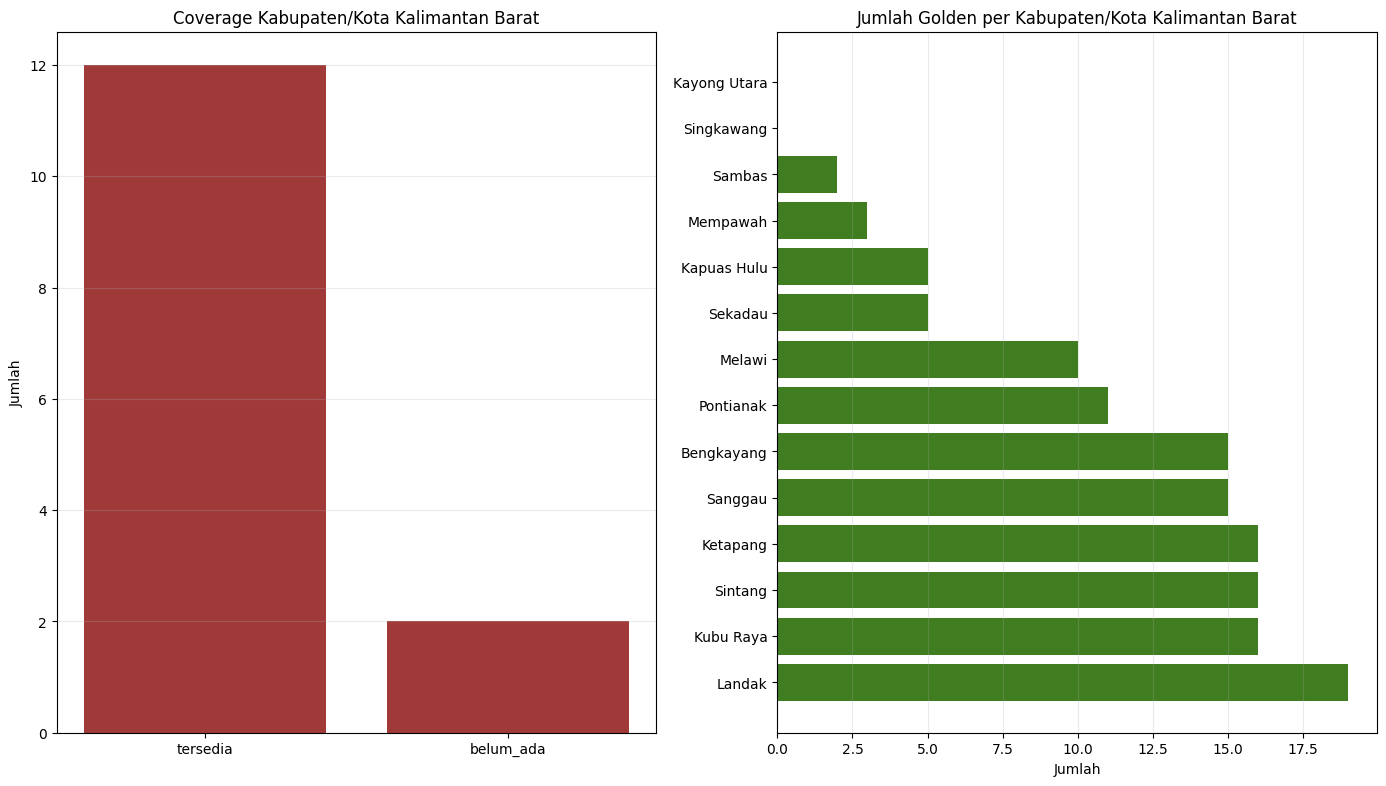

In [8]:
def normalize_location_name(value):
    value = value.casefold().strip()
    value = re.sub(r"\b(kabupaten|kab\.?|kota)\b", "", value)
    value = re.sub(r"[^a-z0-9]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()


def clean_region_display(value):
    value = re.sub(r"^(KABUPATEN|KOTA)\s+", "", value.strip(), flags=re.IGNORECASE)
    return value.title()


kalbar_regions = []
with KABUPATEN_PATH.open(newline="", encoding="utf-8-sig") as file:
    reader = csv.DictReader(file)
    for row in reader:
        if str(row.get("parent_code", "")).strip() == "61":
            name = row.get("name", "").strip()
            kalbar_regions.append({
                "region": clean_region_display(name),
                "normalized_region": normalize_location_name(name),
            })

golden_location_counts = Counter(normalize_location_name(row["location"]) for row in rows)
coverage_rows = []
for region in kalbar_regions:
    count = golden_location_counts.get(region["normalized_region"], 0)
    coverage_rows.append({
        "region": region["region"],
        "jumlah_golden": count,
        "coverage_status": "tersedia" if count else "belum_ada",
    })

coverage_df = pl.DataFrame(coverage_rows).sort(["coverage_status", "jumlah_golden", "region"], descending=[False, True, False])
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(coverage_df)

coverage_counts = Counter(row["coverage_status"] for row in coverage_rows)
region_counts = {row["region"]: row["jumlah_golden"] for row in sorted(coverage_rows, key=lambda item: item["jumlah_golden"])}

plot_count_grid(
    [
        {
            "data": dict(coverage_counts),
            "title": "Coverage Kabupaten/Kota Kalimantan Barat",
            "color": RED_COLOR,
            "rotate": 0,
        },
        {
            "data": region_counts,
            "title": "Jumlah Golden per Kabupaten/Kota Kalimantan Barat",
            "chart_type": "horizontal",
            "color": GREEN_COLOR,
        },
    ],
    "golden_kalbar_location_coverage.png",
    row_height=8,
    col_width=7,
)


## 8. Kandidat Area Kurang


In [9]:
missing_location_df = coverage_df.filter(pl.col("coverage_status") == "belum_ada")
low_location_df = coverage_df.filter((pl.col("coverage_status") == "tersedia") & (pl.col("jumlah_golden") < 5))

sentiment_df = (
    df.group_by("sentiment")
    .agg(pl.len().alias("jumlah"))
    .sort("jumlah")
) if df.height else pl.DataFrame()

print("Lokasi Kalbar yang belum ada di golden dataset:")
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(missing_location_df)

print("Lokasi Kalbar yang masih rendah (<5 data):")
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(low_location_df)

print("Sentimen dari jumlah terendah:")
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    display(sentiment_df)


Lokasi Kalbar yang belum ada di golden dataset:


region,jumlah_golden,coverage_status
str,i64,str
"""Kayong Utara""",0,"""belum_ada"""
"""Singkawang""",0,"""belum_ada"""


Lokasi Kalbar yang masih rendah (<5 data):


region,jumlah_golden,coverage_status
str,i64,str
"""Mempawah""",3,"""tersedia"""
"""Sambas""",2,"""tersedia"""


Sentimen dari jumlah terendah:


sentiment,jumlah
str,u32
"""netral""",1
"""negatif""",58
"""positif""",104


## 9. Preview Data untuk Review Manual


In [10]:
preview_columns = ["golden_file", "text_id", "sentiment", "location", "word_count", "text"]
preview_df = df.select(preview_columns).sort(["location", "sentiment", "text_id"]) if df.height else df
with pl.Config(tbl_rows=30, tbl_cols=-1, fmt_str_lengths=140):
    display(preview_df)


golden_file,text_id,sentiment,location,word_count,text
str,str,str,str,i64,str
"""1_sentiment_labeling_output.json""","""RAW-0908#01""","""negatif""","""Bengkayang""",23,"""Hal ini menunjukkan bahwa sejumlah proyek pembangkit listrik, seperti PLTU Bengkayang dan PLTU Parit Baru, mengalami penundaan yang cukup si…"
"""2_sentiment_labeling_output.json""","""RAW-1034#01""","""negatif""","""Bengkayang""",10,"""Aksesnya sulit, tanpa listrik, sinyal handphone, bahkan aliran air bersih."""
"""2_sentiment_labeling_output.json""","""RAW-1034#02""","""negatif""","""Bengkayang""",12,"""Yang saya bayangkan, terus gimana belajarnya kalau HP, sinyal, listrik tidak ada?"""
"""2_sentiment_labeling_output.json""","""RAW-1034#03""","""negatif""","""Bengkayang""",12,"""Listrik aja jarang di Kabupaten Bengkayang, apalagi sinyal Kita bahas sinyal dulu."""
"""2_sentiment_labeling_output.json""","""RAW-1034#04""","""negatif""","""Bengkayang""",12,"""Jalan 1 jam untuk ngecharge HP, hidup di Kabupaten Bengkayang memang berat"""
"""2_sentiment_labeling_output.json""","""RAW-1034#05""","""negatif""","""Bengkayang""",14,"""Mereka rela berjalan 1 jam dengan kegelapan jalan menembus belantara untuk mengisi daya handphone."""
"""2_sentiment_labeling_output.json""","""RAW-1034#06""","""negatif""","""Bengkayang""",15,"""Buat warga di sini, siapapun presidennya, bahkan siapapun bupatinya, tipis harapan bisa mengubah nasib mereka."""
"""1_sentiment_labeling_output.json""","""RAW-0033#01""","""positif""","""Bengkayang""",48,"""Program Lisdes nyata dirasakan oleh Kasius, Kepala Desa Sukabangun, Kabupaten Bengkayang, Kalimantan Barat. Senyumnya melebar saat mencerita…"
"""2_sentiment_labeling_output.json""","""RAW-0864#01""","""positif""","""Bengkayang""",28,"""Manager PLN UP3 Singkawang, Made Hary Palguna, menegaskan bahwa keselamatan ketenagalistrikan merupakan bagian penting dari upaya PLN dalam …"
